# **Working with Videos**

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from sam2.build_sam import build_sam2_video_predictor

predictor = build_sam2_video_predictor(model_cfg, checkpoint, device=device)

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

# New Section - Part 1

Mounted at /content/drive


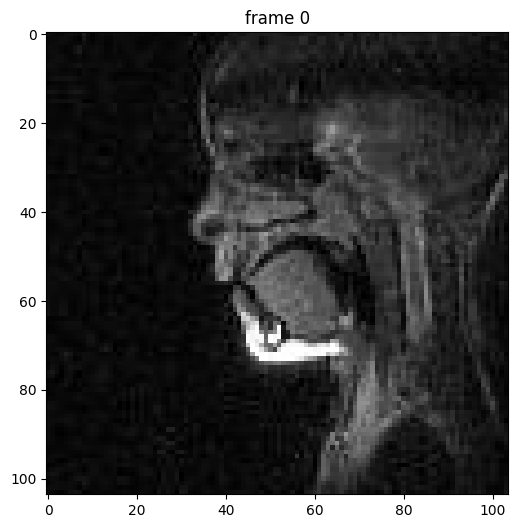

In [ ]:
import os

drive.mount('/content/drive', force_remount=True)
video_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/img_pt1'

for filename in os.listdir(video_dir):
    if filename.startswith("frame") and filename.endswith((".jpg", ".jpeg", ".JPG", ".JPEG")):
        new_name = filename[5:]
        os.rename(os.path.join(video_dir, filename), os.path.join(video_dir, new_name))

video_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/img_pt1'
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]

frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
for frame_idx in range(len(frame_names)):
    frame_path = os.path.join(video_dir, frame_names[frame_idx])
    grayscale_image = Image.open(frame_path).convert('L')

frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(grayscale_image, cmap='gray')

In [ ]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 501/501 [00:11<00:00, 41.99it/s]


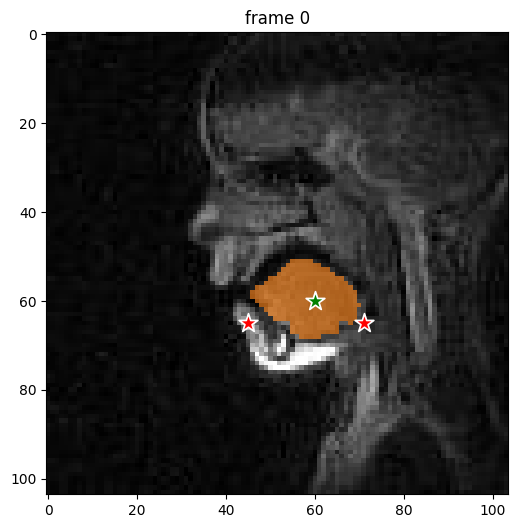

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[60,60],[45,65],[71,65]], dtype=np.float32)
labels = np.array([1,0,0], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))

plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [ ]:
video_segments = {}
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 501/501 [03:27<00:00,  2.42it/s]


In [ ]:
predictor.reset_state(inference_state)

In [ ]:
prompts = {}

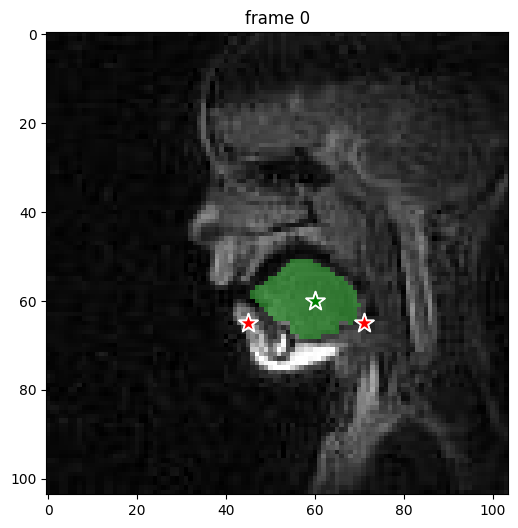

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[60,60],[45,65],[71,65]], dtype=np.float32)
labels = np.array([1,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[60,60],[45,65],[71,65]], dtype=np.float32)
labels = np.array([1,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


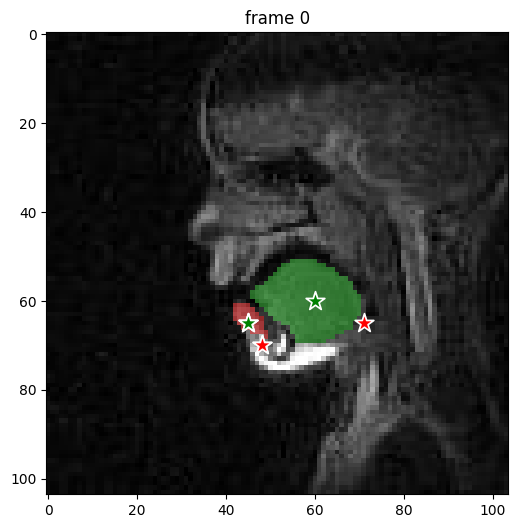

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 3  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,65],[48,70]], dtype=np.float32)
labels = np.array([1,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


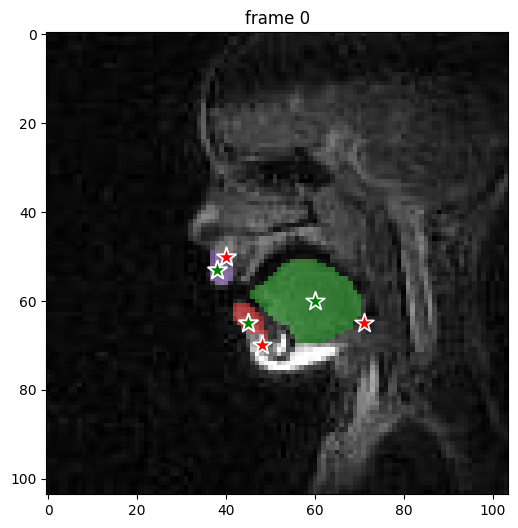

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 4  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[38,53],[40,50]], dtype=np.float32)
labels = np.array([1,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

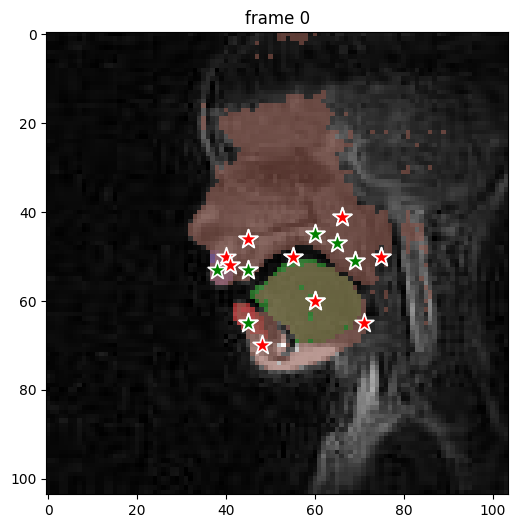

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

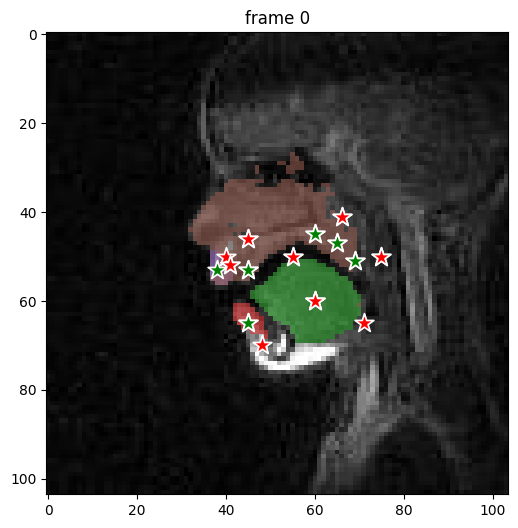

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

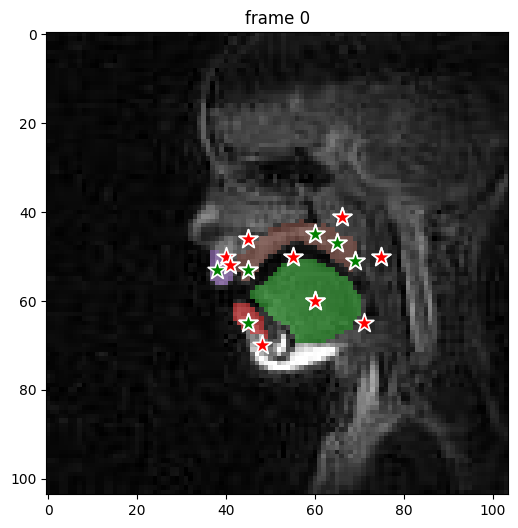

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

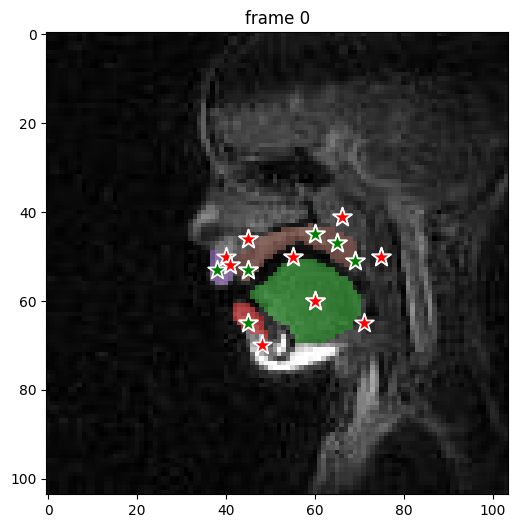

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

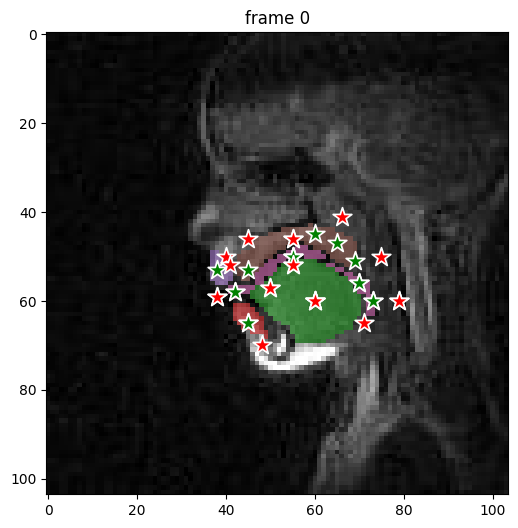

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 6  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[55,50],[55,52],[55,46],[42,58],[38,59],[70,56],[73,60],[79,60],[60,60],[50,57]], dtype=np.float32)
labels = np.array([1,0,0,1,0,1,1,0,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

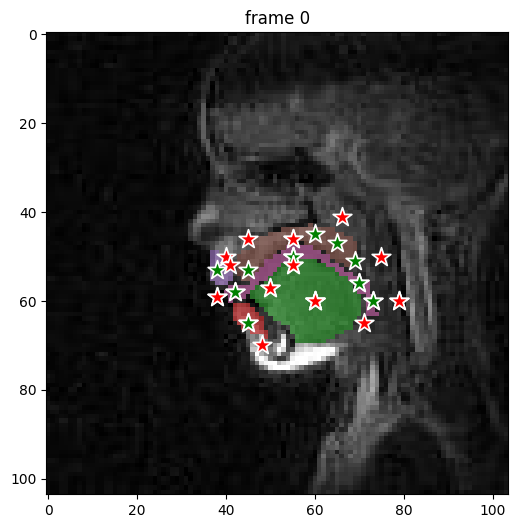

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 6  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[55,50],[55,52],[55,46],[42,58],[38,59],[70,56],[73,60],[79,60],[60,60],[50,57]], dtype=np.float32)
labels = np.array([1,0,0,1,0,1,1,0,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

In [ ]:
video_segments = {}
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 501/501 [06:35<00:00,  1.27it/s]


In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os
import io

output_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/output/overlay'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

vis_frame_stride = 1
image_counter = 101

for out_frame_idx in range(0, len(frame_names), vis_frame_stride):

    if out_frame_idx == 0:
        print(f"Skipping frame {out_frame_idx}")
        continue

    img = Image.open(os.path.join(video_dir, frame_names[out_frame_idx])).convert('L')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(f"frame {out_frame_idx}")
    ax.imshow(img, cmap='gray')

    if out_frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            show_mask(out_mask, ax, obj_id=out_obj_id)

    buf = io.BytesIO()
    fig.savefig(buf, format='jpeg')
    buf.seek(0)
    pil_img = Image.open(buf)

    jpeg_path = os.path.join(output_dir, f"segmented_frame_{image_counter:04}.jpg")
    pil_img.save(jpeg_path, "JPEG", quality=95)  # Save with compression quality 95
    plt.close(fig)
    image_counter += 1

Skipping frame 0
Segmented frame 3601 saved as JPEG to Google Drive.
Segmented frame 3602 saved as JPEG to Google Drive.
Segmented frame 3603 saved as JPEG to Google Drive.
Segmented frame 3604 saved as JPEG to Google Drive.
Segmented frame 3605 saved as JPEG to Google Drive.
Segmented frame 3606 saved as JPEG to Google Drive.
Segmented frame 3607 saved as JPEG to Google Drive.
Segmented frame 3608 saved as JPEG to Google Drive.
Segmented frame 3609 saved as JPEG to Google Drive.
Segmented frame 3610 saved as JPEG to Google Drive.
Segmented frame 3611 saved as JPEG to Google Drive.
Segmented frame 3612 saved as JPEG to Google Drive.
Segmented frame 3613 saved as JPEG to Google Drive.
Segmented frame 3614 saved as JPEG to Google Drive.
Segmented frame 3615 saved as JPEG to Google Drive.
Segmented frame 3616 saved as JPEG to Google Drive.
Segmented frame 3617 saved as JPEG to Google Drive.
Segmented frame 3618 saved as JPEG to Google Drive.
Segmented frame 3619 saved as JPEG to Google Dr

In [ ]:
# NEW get csv for masks

from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os
import io
import numpy as np
import pandas as pd

object_data = {}

output_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/output/maskonly'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

vis_frame_stride = 1
image_counter = 101

for out_frame_idx in range(0, len(video_segments), vis_frame_stride):

    if out_frame_idx == 0:
        print(f"Skipping frame {out_frame_idx}")
        continue

    img_size = (106,106)
    img = Image.new("RGB", img_size, color=(0, 0, 0))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f"Frame {out_frame_idx}")
    ax.imshow(img)

    if out_frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            mask = np.array(out_mask)
            mask = np.squeeze(mask)
            if mask.ndim == 3:
                mask = mask[..., 0]

            coords = np.column_stack(np.where(mask > 0))

            if coords.size == 0:
                continue

            frame_label = f"mask_{image_counter:04}"

            if out_obj_id not in object_data:
                object_data[out_obj_id] = []

            for y, x in coords:
                object_data[out_obj_id].append([
                    frame_label,
                    x,
                    y
                ])

            show_mask(mask, ax, obj_id=out_obj_id)

    buf = io.BytesIO()
    fig.savefig(buf, format='jpeg')
    buf.seek(0)
    pil_img = Image.open(buf)
    jpeg_path = os.path.join(output_dir, f"mask_{image_counter:04}.jpg")
    pil_img.save(jpeg_path, "JPEG", quality=95)
    plt.close(fig)
    image_counter += 1

for obj_id, rows in object_data.items():
    df = pd.DataFrame(rows, columns=["frame_label", "x", "y"])
    csv_filename = f"mask_{obj_id}_spk3bvt1.csv"
    csv_path = os.path.join(output_dir, csv_filename)

    df.to_csv(
        csv_path,
        mode='a',  # append
        header=not os.path.exists(csv_path),
        index=False
    )

    print(f"CSV for object {obj_id} has been uploaded :)")


Skipping frame 0
Segmented frame 3601 saved as JPEG to Google Drive.
Segmented frame 3602 saved as JPEG to Google Drive.
Segmented frame 3603 saved as JPEG to Google Drive.
Segmented frame 3604 saved as JPEG to Google Drive.
Segmented frame 3605 saved as JPEG to Google Drive.
Segmented frame 3606 saved as JPEG to Google Drive.
Segmented frame 3607 saved as JPEG to Google Drive.
Segmented frame 3608 saved as JPEG to Google Drive.
Segmented frame 3609 saved as JPEG to Google Drive.
Segmented frame 3610 saved as JPEG to Google Drive.
Segmented frame 3611 saved as JPEG to Google Drive.
Segmented frame 3612 saved as JPEG to Google Drive.
Segmented frame 3613 saved as JPEG to Google Drive.
Segmented frame 3614 saved as JPEG to Google Drive.
Segmented frame 3615 saved as JPEG to Google Drive.
Segmented frame 3616 saved as JPEG to Google Drive.
Segmented frame 3617 saved as JPEG to Google Drive.
Segmented frame 3618 saved as JPEG to Google Drive.
Segmented frame 3619 saved as JPEG to Google Dr

# New Section - Part 2

Mounted at /content/drive


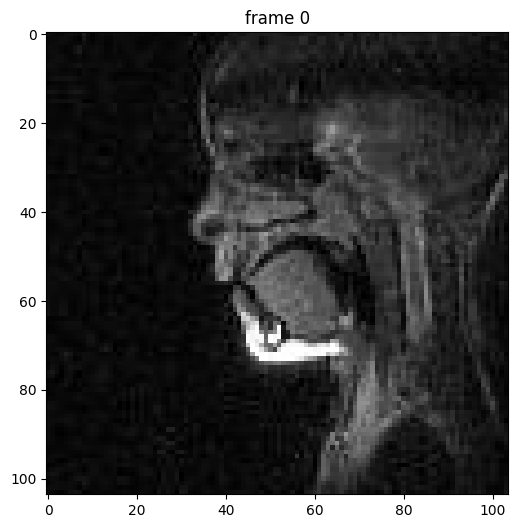

In [ ]:
import os

drive.mount('/content/drive', force_remount=True)
video_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/img_pt2'

for filename in os.listdir(video_dir):
    if filename.startswith("frame") and filename.endswith((".jpg", ".jpeg", ".JPG", ".JPEG")):
        new_name = filename[5:]
        os.rename(os.path.join(video_dir, filename), os.path.join(video_dir, new_name))

video_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/img_pt2'
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]

frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
for frame_idx in range(len(frame_names)):
    frame_path = os.path.join(video_dir, frame_names[frame_idx])
    grayscale_image = Image.open(frame_path).convert('L')

frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(grayscale_image, cmap='gray')

In [ ]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 501/501 [00:11<00:00, 41.99it/s]


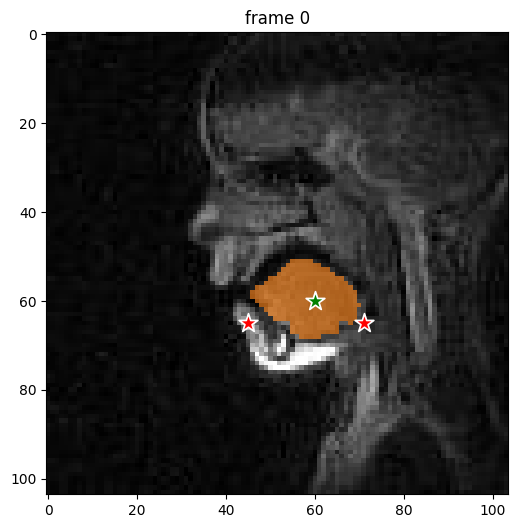

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[60,60],[45,65],[71,65]], dtype=np.float32)
labels = np.array([1,0,0], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))

plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [ ]:
video_segments = {}
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 501/501 [03:27<00:00,  2.42it/s]


In [ ]:
predictor.reset_state(inference_state)

In [ ]:
prompts = {}

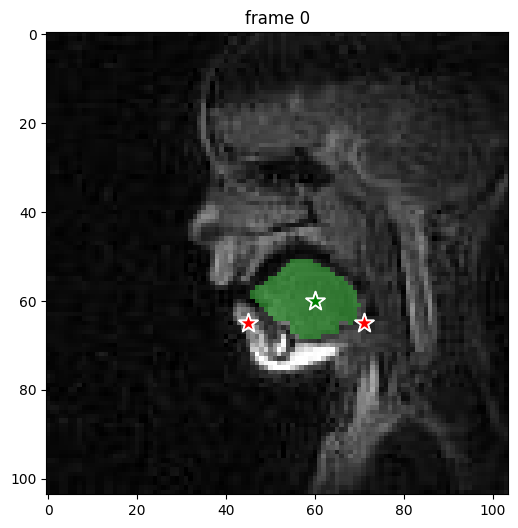

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[60,60],[45,65],[71,65]], dtype=np.float32)
labels = np.array([1,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[60,60],[45,65],[71,65]], dtype=np.float32)
labels = np.array([1,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


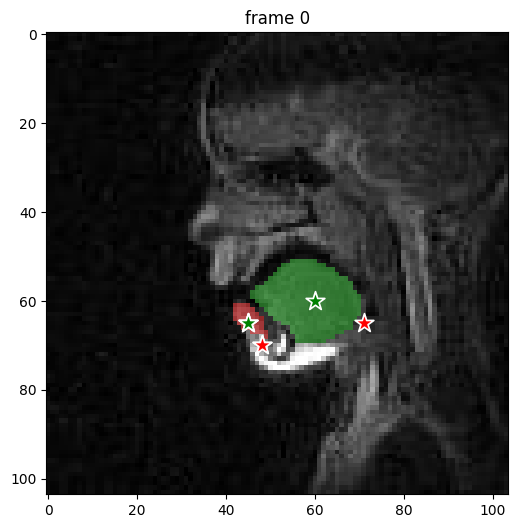

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 3  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,65],[48,70]], dtype=np.float32)
labels = np.array([1,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


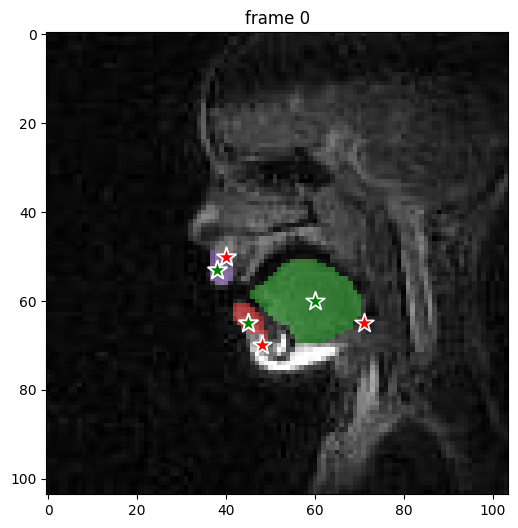

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 4  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[38,53],[40,50]], dtype=np.float32)
labels = np.array([1,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

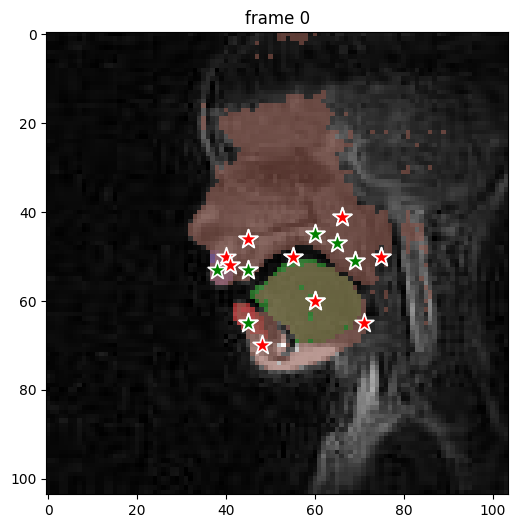

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

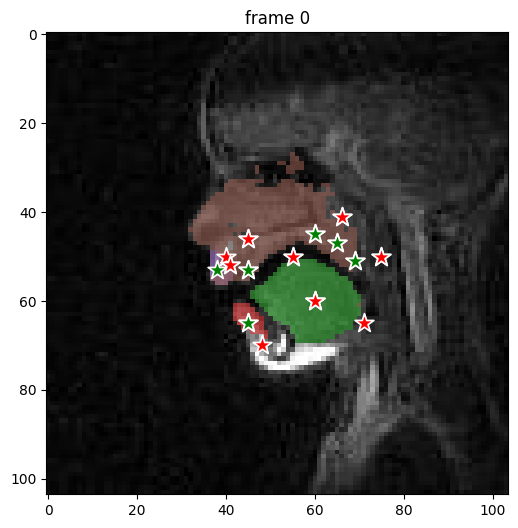

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

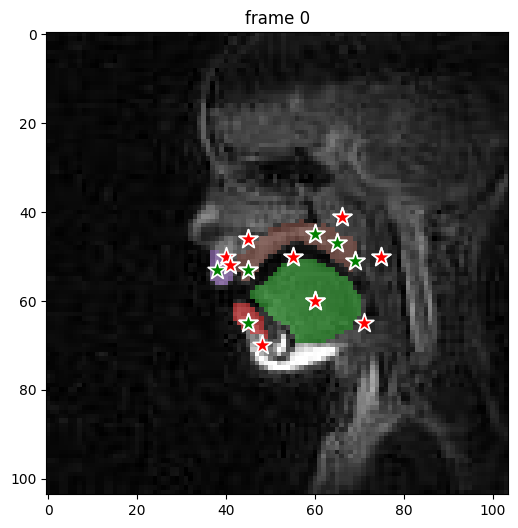

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

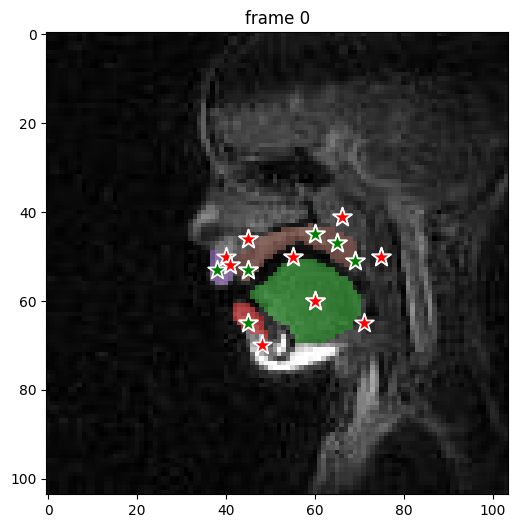

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 5  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[45,53],[45,46],[66,41],[60,45],[75,50],[55,50],[60,60],[69,51],[41,52],[65,47]], dtype=np.float32)
labels = np.array([1,0,0,1,0,0,0,1,0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

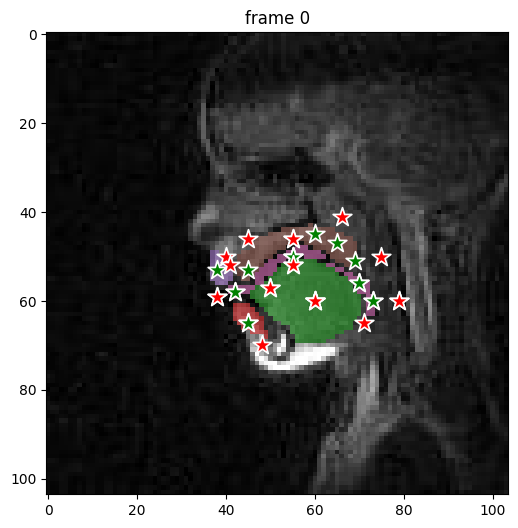

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 6  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[55,50],[55,52],[55,46],[42,58],[38,59],[70,56],[73,60],[79,60],[60,60],[50,57]], dtype=np.float32)
labels = np.array([1,0,0,1,0,1,1,0,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

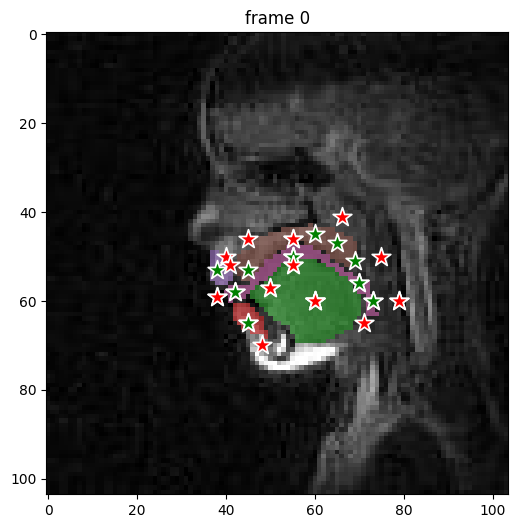

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 6  # give a unique id to each object we interact with (it can be any integers)

points = np.array([[55,50],[55,52],[55,46],[42,58],[38,59],[70,56],[73,60],[79,60],[60,60],[50,57]], dtype=np.float32)
labels = np.array([1,0,0,1,0,1,1,0,0,0], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

In [ ]:
video_segments = {}
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 501/501 [06:35<00:00,  1.27it/s]


In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os
import io

output_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/output/overlay'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

vis_frame_stride = 1
image_counter = 601

for out_frame_idx in range(0, len(frame_names), vis_frame_stride):

    if out_frame_idx == 0:
        print(f"Skipping frame {out_frame_idx}")
        continue

    img = Image.open(os.path.join(video_dir, frame_names[out_frame_idx])).convert('L')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(f"frame {out_frame_idx}")
    ax.imshow(img, cmap='gray')

    if out_frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            show_mask(out_mask, ax, obj_id=out_obj_id)

    buf = io.BytesIO()
    fig.savefig(buf, format='jpeg')
    buf.seek(0)
    pil_img = Image.open(buf)

    jpeg_path = os.path.join(output_dir, f"segmented_frame_{image_counter:04}.jpg")
    pil_img.save(jpeg_path, "JPEG", quality=95)  # Save with compression quality 95
    plt.close(fig)
    image_counter += 1

Skipping frame 0
Segmented frame 3601 saved as JPEG to Google Drive.
Segmented frame 3602 saved as JPEG to Google Drive.
Segmented frame 3603 saved as JPEG to Google Drive.
Segmented frame 3604 saved as JPEG to Google Drive.
Segmented frame 3605 saved as JPEG to Google Drive.
Segmented frame 3606 saved as JPEG to Google Drive.
Segmented frame 3607 saved as JPEG to Google Drive.
Segmented frame 3608 saved as JPEG to Google Drive.
Segmented frame 3609 saved as JPEG to Google Drive.
Segmented frame 3610 saved as JPEG to Google Drive.
Segmented frame 3611 saved as JPEG to Google Drive.
Segmented frame 3612 saved as JPEG to Google Drive.
Segmented frame 3613 saved as JPEG to Google Drive.
Segmented frame 3614 saved as JPEG to Google Drive.
Segmented frame 3615 saved as JPEG to Google Drive.
Segmented frame 3616 saved as JPEG to Google Drive.
Segmented frame 3617 saved as JPEG to Google Drive.
Segmented frame 3618 saved as JPEG to Google Drive.
Segmented frame 3619 saved as JPEG to Google Dr

In [ ]:
# NEW get csv for masks

from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os
import io
import numpy as np
import pandas as pd

object_data = {}

output_dir = '/content/drive/My Drive/MRI project (Sp2025)/Sean_data_sp3/spk3_bvt1/output/maskonly'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

vis_frame_stride = 1
image_counter = 601

for out_frame_idx in range(0, len(video_segments), vis_frame_stride):

    if out_frame_idx == 0:
        print(f"Skipping frame {out_frame_idx}")
        continue

    img_size = (106,106)
    img = Image.new("RGB", img_size, color=(0, 0, 0))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f"Frame {out_frame_idx}")
    ax.imshow(img)

    if out_frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            mask = np.array(out_mask)
            mask = np.squeeze(mask)
            if mask.ndim == 3:
                mask = mask[..., 0]

            coords = np.column_stack(np.where(mask > 0))

            if coords.size == 0:
                continue

            frame_label = f"mask_{image_counter:04}"

            if out_obj_id not in object_data:
                object_data[out_obj_id] = []

            for y, x in coords:
                object_data[out_obj_id].append([
                    frame_label,
                    x,
                    y
                ])

            show_mask(mask, ax, obj_id=out_obj_id)

    buf = io.BytesIO()
    fig.savefig(buf, format='jpeg')
    buf.seek(0)
    pil_img = Image.open(buf)
    jpeg_path = os.path.join(output_dir, f"mask_{image_counter:04}.jpg")
    pil_img.save(jpeg_path, "JPEG", quality=95)
    plt.close(fig)
    image_counter += 1

for obj_id, rows in object_data.items():
    df = pd.DataFrame(rows, columns=["frame_label", "x", "y"])
    csv_filename = f"mask_{obj_id}_spk3bvt1.csv"
    csv_path = os.path.join(output_dir, csv_filename)

    df.to_csv(
        csv_path,
        mode='a',  # append
        header=not os.path.exists(csv_path),
        index=False
    )

    print(f"CSV for object {obj_id} has been uploaded :)")


Skipping frame 0
Segmented frame 3601 saved as JPEG to Google Drive.
Segmented frame 3602 saved as JPEG to Google Drive.
Segmented frame 3603 saved as JPEG to Google Drive.
Segmented frame 3604 saved as JPEG to Google Drive.
Segmented frame 3605 saved as JPEG to Google Drive.
Segmented frame 3606 saved as JPEG to Google Drive.
Segmented frame 3607 saved as JPEG to Google Drive.
Segmented frame 3608 saved as JPEG to Google Drive.
Segmented frame 3609 saved as JPEG to Google Drive.
Segmented frame 3610 saved as JPEG to Google Drive.
Segmented frame 3611 saved as JPEG to Google Drive.
Segmented frame 3612 saved as JPEG to Google Drive.
Segmented frame 3613 saved as JPEG to Google Drive.
Segmented frame 3614 saved as JPEG to Google Drive.
Segmented frame 3615 saved as JPEG to Google Drive.
Segmented frame 3616 saved as JPEG to Google Drive.
Segmented frame 3617 saved as JPEG to Google Drive.
Segmented frame 3618 saved as JPEG to Google Drive.
Segmented frame 3619 saved as JPEG to Google Dr